In [13]:
import pandas as pd

data = {
    "review": [
        "The product is excellent and works perfectly.",
        "I really loved this product. Great quality.",
        "Amazing experience, I would definitely buy again.",
        "The service was fast and very helpful.",
        "Excellent value for money.",
        "I am very happy with my purchase.",
        "The quality is outstanding.",
        "Fantastic product and beautiful design.",
        "Delivery was quick and the product was perfect.",
        "This is one of the best products I have bought.",

        "The product is okay.",
        "It is an average product for the price.",
        "The experience was neither good nor bad.",
        "The product is fine, but nothing special.",
        "It works as expected.",
        "The quality is acceptable.",
        "I have mixed feelings about this product.",
        "The service was normal.",
        "The product meets basic requirements.",
        "It is decent for occasional use.",

        "The product is terrible and stopped working.",
        "Very bad quality and poor service.",
        "I hated the experience.",
        "The product was disappointing.",
        "I am unhappy with this purchase.",
        "The delivery was late and the package was damaged.",
        "The product does not work properly.",
        "Worst customer service I have experienced.",
        "The quality is extremely poor.",
        "I regret buying this product."
    ]
}

df = pd.DataFrame(data)

df.head()

,review
0,The product is excellent and works perfectly.
1,I really loved this product. Great quality.
2,"Amazing experience, I would definitely buy again."
3,The service was fast and very helpful.
4,Excellent value for money.


In [14]:
print("Total number of reviews:", len(df))

print("\nMissing values:")
print(df.isnull().sum())

Total number of reviews: 30

Missing values:
review    0
dtype: int64


In [15]:
!pip install vaderSentiment

In [16]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [17]:
def get_sentiment(review):
    score = analyzer.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["review"].apply(get_sentiment)

df.head(10)

,review,Sentiment
0,The product is excellent and works perfectly.,Positive
1,I really loved this product. Great quality.,Positive
2,"Amazing experience, I would definitely buy again.",Positive
3,The service was fast and very helpful.,Positive
4,Excellent value for money.,Positive
5,I am very happy with my purchase.,Positive
6,The quality is outstanding.,Positive
7,Fantastic product and beautiful design.,Positive
8,Delivery was quick and the product was perfect.,Positive
9,This is one of the best products I have bought.,Positive


In [18]:
df

,review,Sentiment
0,The product is excellent and works perfectly.,Positive
1,I really loved this product. Great quality.,Positive
2,"Amazing experience, I would definitely buy again.",Positive
3,The service was fast and very helpful.,Positive
4,Excellent value for money.,Positive
5,I am very happy with my purchase.,Positive
6,The quality is outstanding.,Positive
7,Fantastic product and beautiful design.,Positive
8,Delivery was quick and the product was perfect.,Positive
9,This is one of the best products I have bought.,Positive


In [19]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    12
Negative    11
Neutral      7
Name: count, dtype: int64


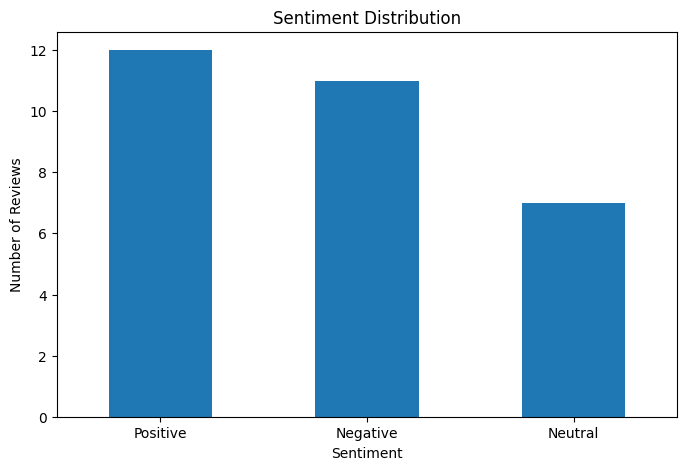

In [20]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(8,5))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

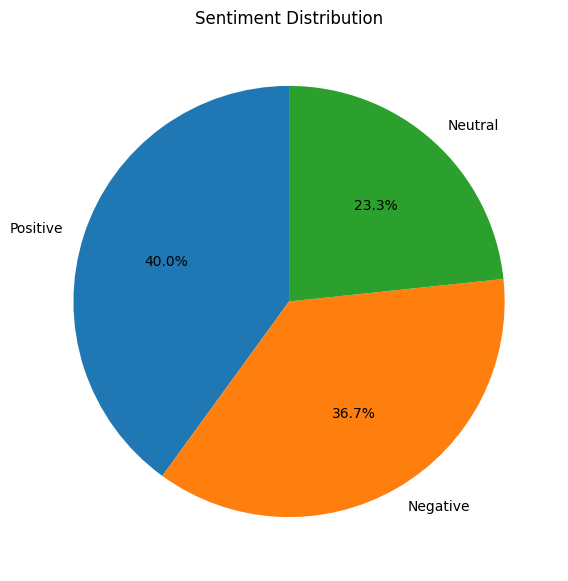

In [21]:
plt.figure(figsize=(7,7))

sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Distribution")
plt.ylabel("")

plt.show()

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Customer Review Word Cloud")

plt.show()

In [ ]:
df.to_csv("sentiment_analysis_results.csv", index=False)

print("File saved successfully!")